# Progetto di Apprendimento Automatico e Apprendimento Profondo
## Classificazione supervisionata sul dataset *Breast Cancer Wisconsin (Diagnostic)*

**Autore:** Andrea Balillo
**Corso:** Apprendimento Automatico e Apprendimento Profondo

---

Questo notebook implementa un esperimento completo di **classificazione binaria** su un dataset del
repository [UCI Machine Learning](https://archive.ics.uci.edu/). Vengono svolti tutti i task richiesti:

1. **Analisi delle feature con PCA** e visualizzazione dei risultati;
2. **Cinque algoritmi di classificazione shallow** (ne erano richiesti almeno tre);
3. **Metriche di valutazione**: *precision, recall, f-measure, accuracy, ROC AUC*;
4. **Visualizzazione** della matrice di confusione e della curva ROC;
5. Entrambe le opzioni del punto 5:
   - **(a)** un approccio di **deep learning** (rete neurale MLP in PyTorch) sugli stessi dati;
   - **(b)** un approccio di **spiegabilità** con **SHAP**.

> **Nota metodologica.** La suddivisione in *training / validation / test* viene definita una sola
> volta ed è utilizzata in modo **identico** dagli algoritmi shallow e dal modello di deep learning,
> come richiesto dalla consegna.

In [1]:
# =====================================================================
# Import delle librerie e configurazione dell'ambiente
# =====================================================================
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay, classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import shap

warnings.filterwarnings("ignore")

# Seed per la riproducibilita' degli esperimenti
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Stile dei grafici
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Cartella di output per le figure e dizionario dei risultati
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
RESULTS = {}

print("Ambiente configurato correttamente.")
print("Versioni principali -> numpy:", np.__version__,
      "| pandas:", pd.__version__,
      "| torch:", torch.__version__,
      "| shap:", shap.__version__)

Ambiente configurato correttamente.
Versioni principali -> numpy: 2.4.6 | pandas: 3.0.3 | torch: 2.13.0+cpu | shap: 0.52.0


## Sezione 1 — Descrizione del dataset

Il dataset scelto è **Breast Cancer Wisconsin (Diagnostic)** (UCI ID 17). Contiene misure calcolate
da immagini digitalizzate di aspirati con ago sottile (FNA) di masse mammarie. Ogni riga descrive un
nucleo cellulare tramite **30 feature numeriche** (raggio, texture, perimetro, area, compattezza,
concavità, ecc., espresse come *media*, *errore standard* e *valore peggiore*).

L'obiettivo è **classificare** ciascuna massa come **maligna** (`malignant`, label 0) o **benigna**
(`benign`, label 1). Si tratta quindi di un problema di **classificazione binaria** — ideale per
calcolare la ROC AUC e per visualizzare la curva ROC.

Il dataset è disponibile direttamente in `scikit-learn` (`load_breast_cancer`), che ne è una copia
fedele: questo garantisce la piena riproducibilità del progetto.

In [2]:
# =====================================================================
# SEZIONE 1 - Caricamento e descrizione del dataset
# Dataset UCI: Breast Cancer Wisconsin (Diagnostic) - ID 17
# =====================================================================
data = load_breast_cancer(as_frame=True)
X = data.data.copy()          # 30 feature numeriche
y = data.target.copy()        # 0 = maligno (malignant), 1 = benigno (benign)
df = data.frame.copy()

feature_names = list(X.columns)
target_names = list(data.target_names)   # ['malignant', 'benign']

print("Numero di campioni :", X.shape[0])
print("Numero di feature  :", X.shape[1])
print("Classi             :", target_names, "-> codifica 0/1")
print("\nPrime righe del dataset:")
df.head()

Numero di campioni : 569
Numero di feature  : 30
Classi             : [np.str_('malignant'), np.str_('benign')] -> codifica 0/1

Prime righe del dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Distribuzione delle classi:
  malignant  (label 0): 212 campioni (37.3%)
  benign     (label 1): 357 campioni (62.7%)



Statistiche descrittive (prime 6 feature):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
count,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104
std,3.524,4.301,24.299,351.914,0.014,0.053
min,6.981,9.710,43.790,143.500,0.053,0.019
25%,11.700,16.170,75.170,420.300,0.086,0.065
50%,13.370,18.840,86.240,551.100,0.096,0.093
75%,15.780,21.800,104.100,782.700,0.105,0.130
max,28.110,39.280,188.500,2501.000,0.163,0.345


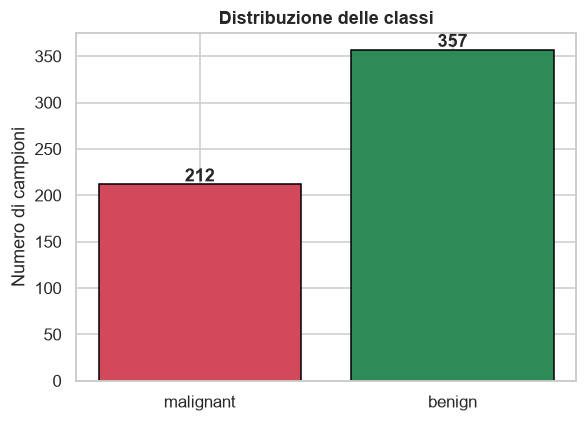

In [3]:
# =====================================================================
# Analisi esplorativa: distribuzione delle classi e statistiche
# =====================================================================
class_counts = y.value_counts().sort_index()
print("Distribuzione delle classi:")
for cls_idx, cnt in class_counts.items():
    print(f"  {target_names[cls_idx]:10s} (label {cls_idx}): {cnt} campioni "
          f"({cnt / len(y) * 100:.1f}%)")

# Grafico della distribuzione delle classi
fig, ax = plt.subplots(figsize=(5.5, 4))
colors = ["#d1495b", "#2e8b57"]
bars = ax.bar([target_names[i] for i in class_counts.index],
              class_counts.values, color=colors, edgecolor="black")
ax.set_title("Distribuzione delle classi")
ax.set_ylabel("Numero di campioni")
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 3, str(v), ha="center", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_class_distribution.png", bbox_inches="tight")

# Statistiche descrittive (prime 6 feature per leggibilita')
print("\nStatistiche descrittive (prime 6 feature):")
df[feature_names[:6]].describe().round(3)

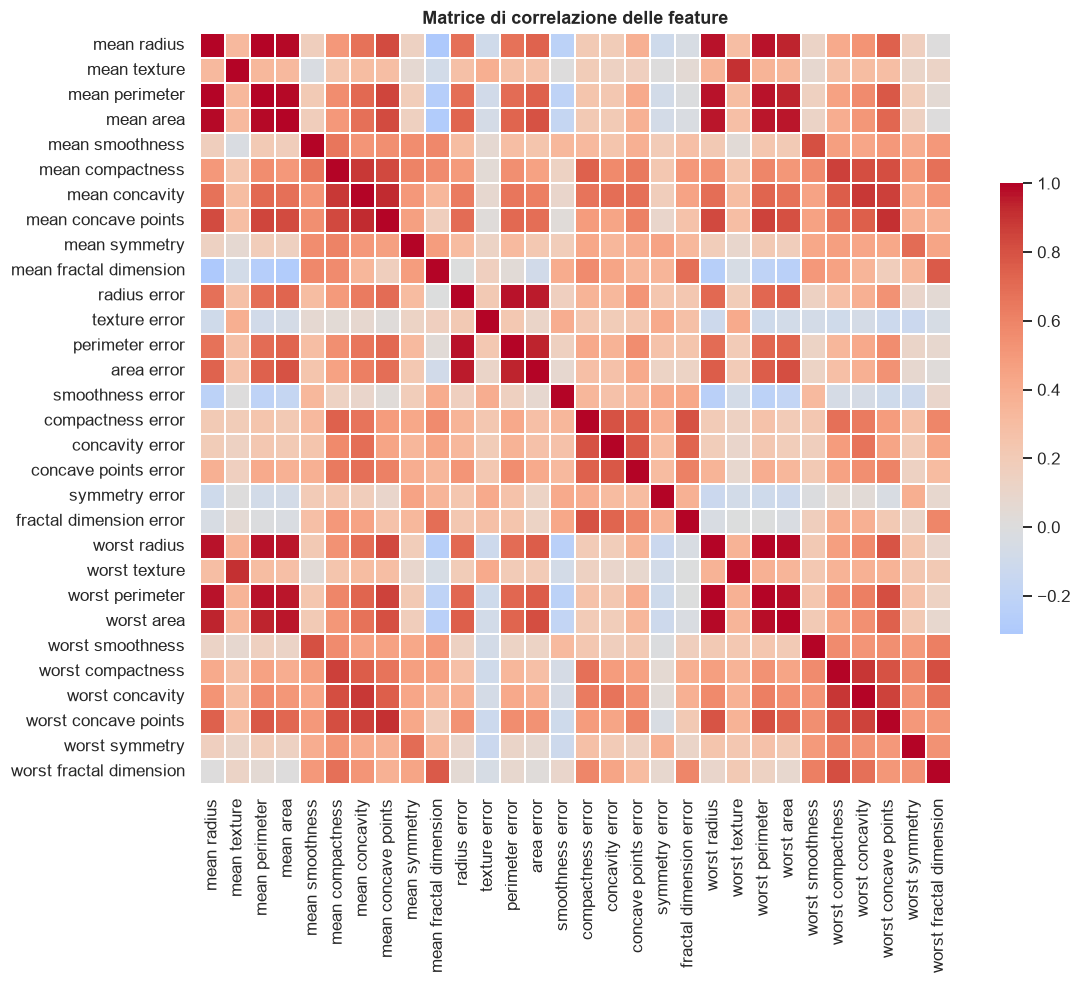

In [4]:
# =====================================================================
# Matrice di correlazione delle 30 feature
# =====================================================================
fig, ax = plt.subplots(figsize=(11, 9))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax,
            linewidths=0.2, cbar_kws={"shrink": 0.6})
ax.set_title("Matrice di correlazione delle feature")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Sezione 2 — Suddivisione dei dati e pre-processing

Adottiamo una suddivisione **stratificata** in tre insiemi:

| Insieme | Percentuale | Scopo |
|---|---|---|
| Training | 60% | Addestramento dei modelli |
| Validation | 20% | Selezione del modello / early stopping |
| Test | 20% | Valutazione finale (dati mai visti) |

La stratificazione mantiene la proporzione tra le classi in tutti gli insiemi. Le feature vengono poi
**standardizzate** (media 0, deviazione standard 1): lo `StandardScaler` viene adattato **solo sul
training set** e applicato a validation e test, per evitare *data leakage*.

⚠️ **Questa identica suddivisione (`X_train_s`, `X_val_s`, `X_test_s`) è quella usata sia dagli
algoritmi shallow sia dalla rete neurale.**

In [5]:
# =====================================================================
# SEZIONE 2 - Suddivisione Train / Validation / Test e standardizzazione
# Split stratificato 60% / 20% / 20%. QUESTA suddivisione viene usata
# in modo IDENTICO per gli algoritmi shallow e per il deep learning.
# =====================================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Training set   : {X_train.shape[0]} campioni")
print(f"Validation set : {X_val.shape[0]} campioni")
print(f"Test set       : {X_test.shape[0]} campioni")

# Standardizzazione: lo scaler viene addestrato SOLO sul training set
# per evitare data leakage, poi applicato a validation e test.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print("\nStandardizzazione completata (media 0, deviazione standard 1 sul training).")

Training set   : 341 campioni
Validation set : 114 campioni
Test set       : 114 campioni

Standardizzazione completata (media 0, deviazione standard 1 sul training).


## Task 1 — Analisi delle feature con la PCA

La **Principal Component Analysis (PCA)** è una tecnica di riduzione della dimensionalità che proietta
i dati su nuove direzioni ortogonali (le *componenti principali*) ordinate per varianza spiegata
decrescente. La usiamo per:

- capire **quanta informazione** è concentrata nelle prime componenti (*scree plot* e varianza cumulata);
- **visualizzare** in 2D un dataset a 30 dimensioni;
- individuare quali feature originali **pesano di più** sulle prime componenti (*loadings*).

La PCA viene adattata sul training set standardizzato.

Varianza spiegata dalle prime 2 componenti: 64.3%
Componenti necessarie per spiegare il 95% della varianza: 10


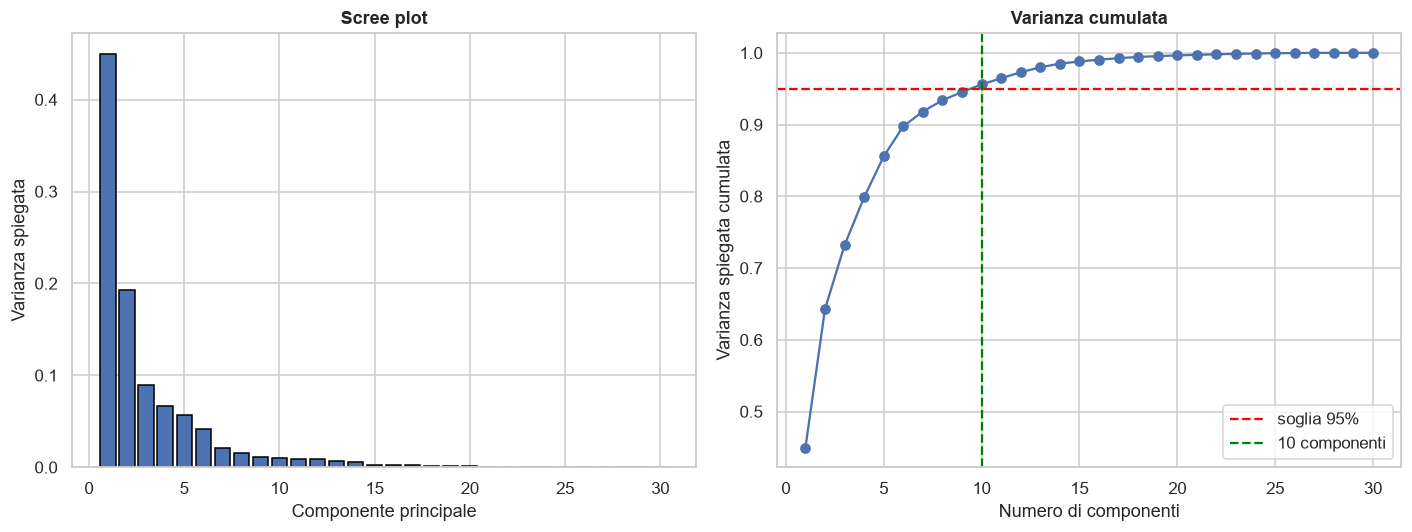

In [6]:
# =====================================================================
# TASK 1 - PCA: analisi della varianza spiegata
# =====================================================================
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_s)
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
n_comp_95 = int(np.argmax(cum_evr >= 0.95) + 1)

print(f"Varianza spiegata dalle prime 2 componenti: {cum_evr[1] * 100:.1f}%")
print(f"Componenti necessarie per spiegare il 95% della varianza: {n_comp_95}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(evr) + 1), evr, color="#4c72b0", edgecolor="black")
axes[0].set_xlabel("Componente principale")
axes[0].set_ylabel("Varianza spiegata")
axes[0].set_title("Scree plot")

axes[1].plot(range(1, len(cum_evr) + 1), cum_evr, marker="o", color="#4c72b0")
axes[1].axhline(0.95, color="red", ls="--", label="soglia 95%")
axes[1].axvline(n_comp_95, color="green", ls="--",
                label=f"{n_comp_95} componenti")
axes[1].set_xlabel("Numero di componenti")
axes[1].set_ylabel("Varianza spiegata cumulata")
axes[1].set_title("Varianza cumulata")
axes[1].legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_pca_scree_cumulative.png", bbox_inches="tight")
plt.show()

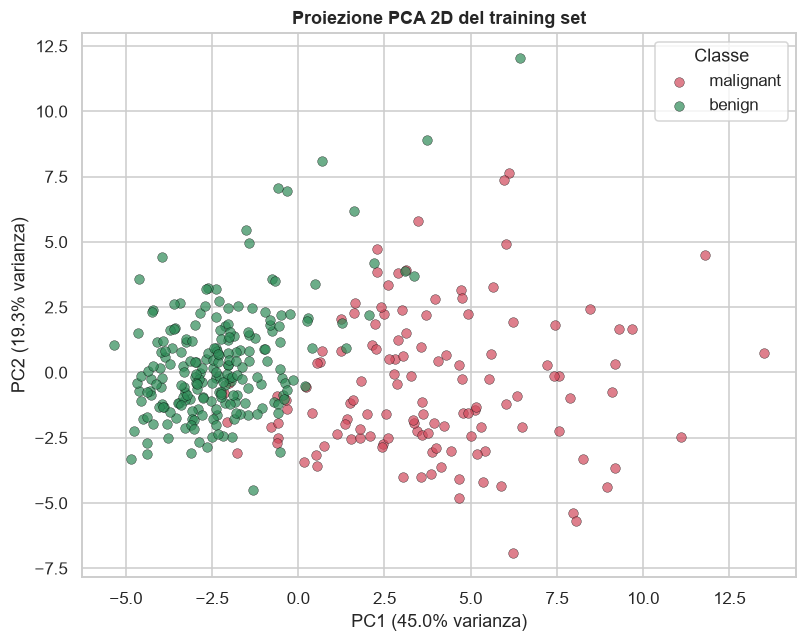

In [7]:
# =====================================================================
# TASK 1 - PCA: proiezione 2D dei dati
# =====================================================================
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_s)
X_train_pca2 = pca2.transform(X_train_s)

fig, ax = plt.subplots(figsize=(7.5, 6))
for cls_idx, color in zip([0, 1], ["#d1495b", "#2e8b57"]):
    mask = (y_train.values == cls_idx)
    ax.scatter(X_train_pca2[mask, 0], X_train_pca2[mask, 1],
               c=color, label=target_names[cls_idx], alpha=0.7,
               edgecolor="black", linewidth=0.3, s=40)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}% varianza)")
ax.set_title("Proiezione PCA 2D del training set")
ax.legend(title="Classe")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_pca_2d_projection.png", bbox_inches="tight")
plt.show()

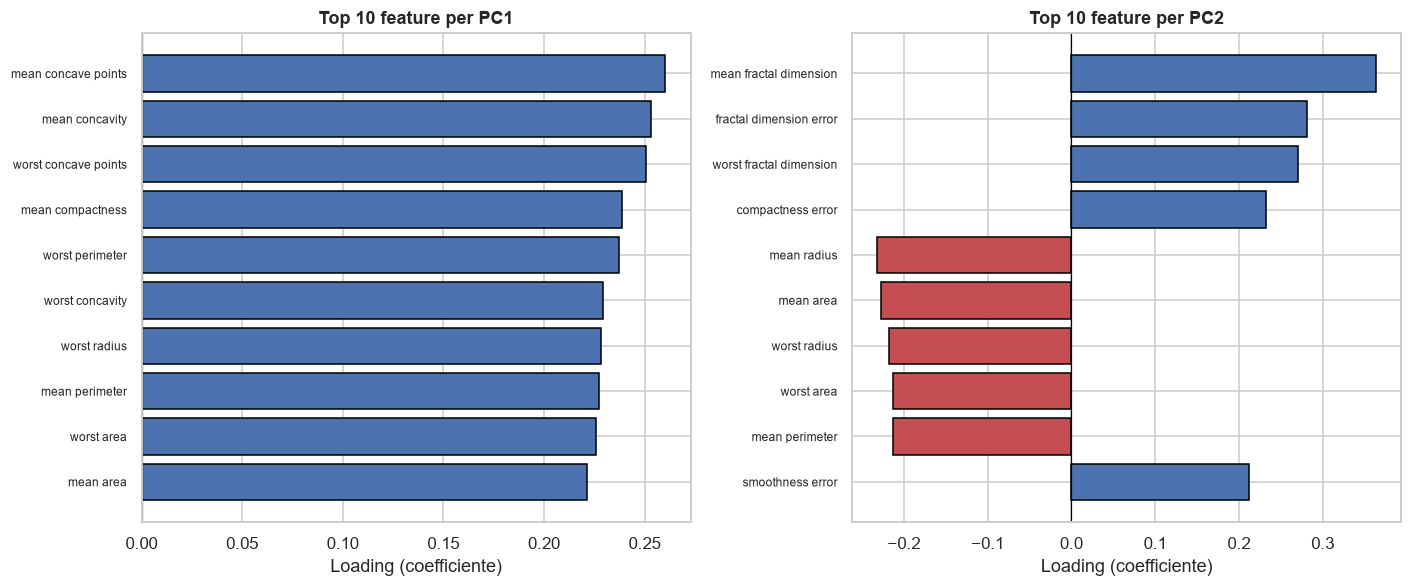

Feature piu' influenti sulla prima componente principale (PC1):
  - mean concave points: +0.260
  - mean concavity: +0.253
  - worst concave points: +0.251
  - mean compactness: +0.239
  - worst perimeter: +0.237


In [8]:
# =====================================================================
# TASK 1 - PCA: contributo delle feature (loadings) alle prime 2 componenti
# =====================================================================
loadings = pd.DataFrame(pca2.components_.T, index=feature_names,
                        columns=["PC1", "PC2"])
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    vals = loadings.loc[top.index, pc]
    ax.barh(range(len(vals)), vals.values,
            color=["#4c72b0" if v >= 0 else "#c44e52" for v in vals.values],
            edgecolor="black")
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top 10 feature per {pc}")
    ax.set_xlabel("Loading (coefficiente)")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_pca_loadings.png", bbox_inches="tight")
plt.show()

print("Feature piu' influenti sulla prima componente principale (PC1):")
for f in top_pc1[:5]:
    print(f"  - {f}: {loadings.loc[f, 'PC1']:+.3f}")

## Task 2 — Algoritmi di classificazione shallow

Implementiamo **cinque** classificatori tra quelli affrontati nel corso (il minimo richiesto è tre):

1. **Logistic Regression** — modello lineare probabilistico;
2. **Support Vector Machine (SVM)** con kernel RBF;
3. **Random Forest** — ensemble di alberi decisionali;
4. **K-Nearest Neighbors (KNN)**;
5. **Naive Bayes** gaussiano.

Ogni modello viene addestrato sul **training set** e valutato su **validation** e **test**. La
funzione `compute_scores` calcola in un colpo solo tutte le metriche richieste.

In [9]:
# =====================================================================
# TASK 2 - Addestramento di 5 algoritmi di classificazione shallow
# =====================================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
}


def compute_scores(model, X_set, y_set):
    """Calcola predizioni, probabilita' e metriche per un modello sklearn."""
    y_pred = model.predict(X_set)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_set)[:, 1]
    else:
        y_proba = model.decision_function(X_set)
    return {
        "accuracy": accuracy_score(y_set, y_pred),
        "precision": precision_score(y_set, y_pred),
        "recall": recall_score(y_set, y_pred),
        "f1": f1_score(y_set, y_pred),
        "roc_auc": roc_auc_score(y_set, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


val_results, test_results = {}, {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)                       # addestramento sul training
    val_results[name] = compute_scores(mdl, X_val_s, y_val)    # selezione modello
    test_results[name] = compute_scores(mdl, X_test_s, y_test)  # valutazione finale
    print(f"{name:22s} -> Val AUC: {val_results[name]['roc_auc']:.3f} | "
          f"Test AUC: {test_results[name]['roc_auc']:.3f}")

Logistic Regression    -> Val AUC: 1.000 | Test AUC: 0.997
SVM (RBF)              -> Val AUC: 0.999 | Test AUC: 0.996


Random Forest          -> Val AUC: 0.996 | Test AUC: 0.990


K-Nearest Neighbors    -> Val AUC: 0.998 | Test AUC: 0.981
Naive Bayes            -> Val AUC: 0.995 | Test AUC: 0.986


## Task 3 — Metriche di valutazione

Per ogni modello calcoliamo, sul **test set**, le cinque metriche richieste:

- **Accuracy** — frazione di predizioni corrette;
- **Precision** — TP / (TP + FP): affidabilità delle predizioni positive;
- **Recall** (sensibilità) — TP / (TP + FN): capacità di individuare i positivi;
- **F1-score (f-measure)** — media armonica di precision e recall;
- **ROC AUC** — area sotto la curva ROC, robusta allo sbilanciamento.

La classe positiva è `benign` (label 1), coerentemente con la codifica di scikit-learn. Viene inoltre
mostrato il `classification_report` completo del miglior modello (con entrambe le classi).

In [10]:
# =====================================================================
# TASK 3 - Metriche di valutazione: precision, recall, f-measure,
#          accuracy, ROC AUC (calcolate sul TEST set)
# =====================================================================
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]

comparison = pd.DataFrame(
    {name: {m: test_results[name][m] for m in metric_cols} for name in models}
).T.sort_values("roc_auc", ascending=False)

best_shallow = comparison.index[0]
print("Confronto delle metriche sul TEST set (ordinato per ROC AUC):\n")
print(comparison.round(4).to_string())
print(f"\nMiglior modello shallow per ROC AUC: {best_shallow}")

# Report dettagliato del miglior modello (entrambe le classi)
print(f"\nClassification report - {best_shallow}:")
print(classification_report(y_test, test_results[best_shallow]["y_pred"],
                            target_names=target_names))

comparison.round(4)

Confronto delle metriche sul TEST set (ordinato per ROC AUC):

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9912     0.9861  1.0000  0.9930   0.9971
SVM (RBF)              0.9649     0.9589  0.9859  0.9722   0.9961
Random Forest          0.9298     0.9565  0.9296  0.9429   0.9902
Naive Bayes            0.9123     0.9067  0.9577  0.9315   0.9859
K-Nearest Neighbors    0.9474     0.9333  0.9859  0.9589   0.9812

Miglior modello shallow per ROC AUC: Logistic Regression

Classification report - Logistic Regression:
              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        43
      benign       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.9912,0.9861,1.0000,0.9930,0.9971
SVM (RBF),0.9649,0.9589,0.9859,0.9722,0.9961
Random Forest,0.9298,0.9565,0.9296,0.9429,0.9902
Naive Bayes,0.9123,0.9067,0.9577,0.9315,0.9859
K-Nearest Neighbors,0.9474,0.9333,0.9859,0.9589,0.9812


## Task 4 — Matrice di confusione e curva ROC

Visualizziamo:

- la **matrice di confusione** di ciascun classificatore shallow (per analizzare falsi positivi e
  falsi negativi in modo clinicamente rilevante);
- le **curve ROC** sovrapposte, con la relativa AUC in legenda.

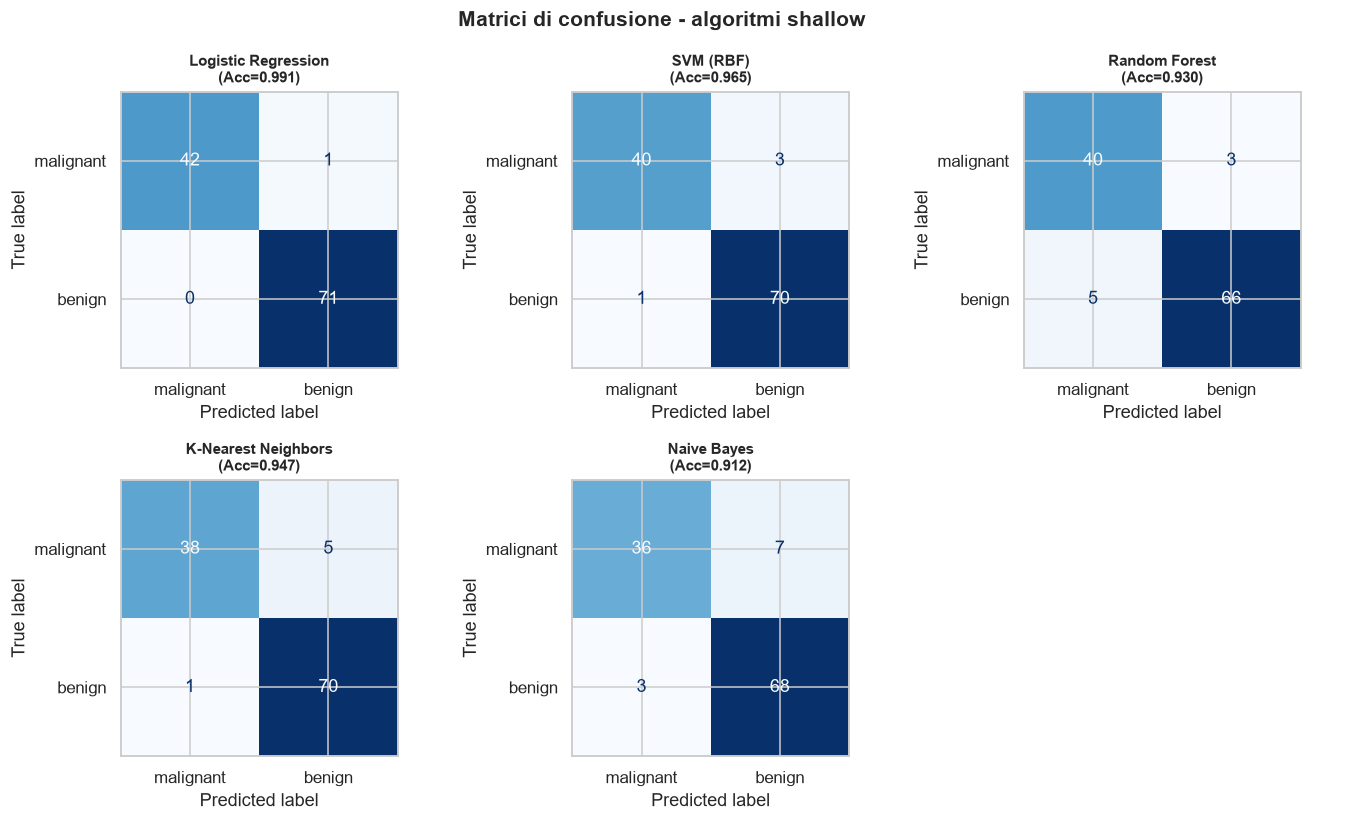

In [11]:
# =====================================================================
# TASK 4 - Matrici di confusione dei modelli shallow (sul TEST set)
# =====================================================================
n_models = len(models)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = axes.ravel()
for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{name}\n(Acc={res['accuracy']:.3f})", fontsize=10)
for ax in axes[n_models:]:
    ax.axis("off")
fig.suptitle("Matrici di confusione - algoritmi shallow", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_confusion_matrices_shallow.png", bbox_inches="tight")
plt.show()

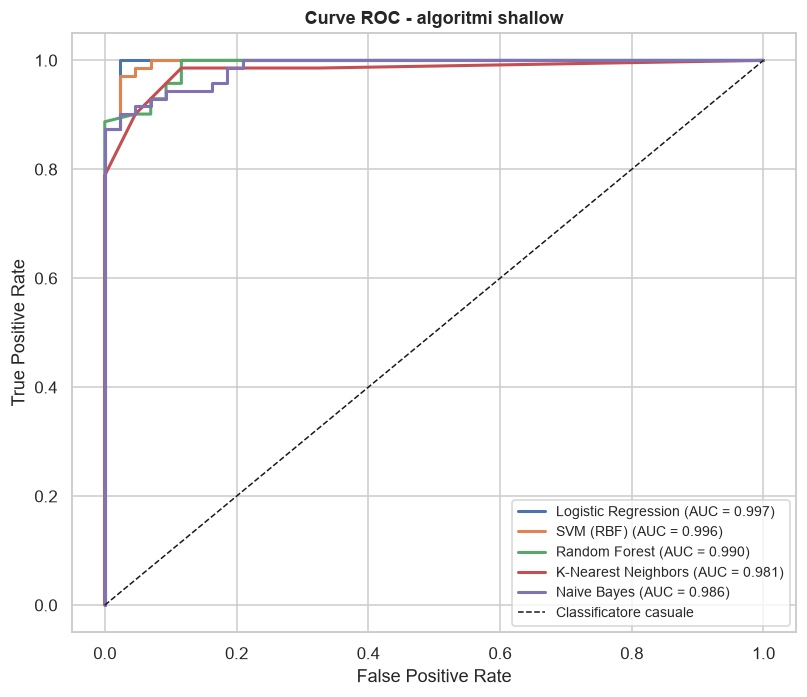

In [12]:
# =====================================================================
# TASK 4 - Curve ROC dei modelli shallow (sul TEST set)
# =====================================================================
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificatore casuale")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curve ROC - algoritmi shallow")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_roc_curves_shallow.png", bbox_inches="tight")
plt.show()

## Task 5a — Approccio di Deep Learning (rete neurale MLP)

Implementiamo un **Percettrone Multi-Strato (MLP)** in **PyTorch**, addestrato sugli **stessi dati
standardizzati** e con la **stessa suddivisione** train/validation/test usata per gli algoritmi shallow.

**Architettura:** `30 → 64 → 32 → 1`, con attivazioni **ReLU**, **Dropout** (0.3 e 0.2) per la
regolarizzazione e uscita a un neurone con **`BCEWithLogitsLoss`** (sigmoide implicita).

**Addestramento:** ottimizzatore **Adam** (`lr=1e-3`, weight decay `1e-4`), mini-batch da 32, con
**early stopping** sulla loss di validation (*patience* = 25 epoche). Questo garantisce che il
validation set svolga lo stesso ruolo di selezione del modello che aveva per gli algoritmi shallow.

Addestramento terminato dopo 92 epoche (early stopping, patience=25).
Migliore loss di validation: 0.0268


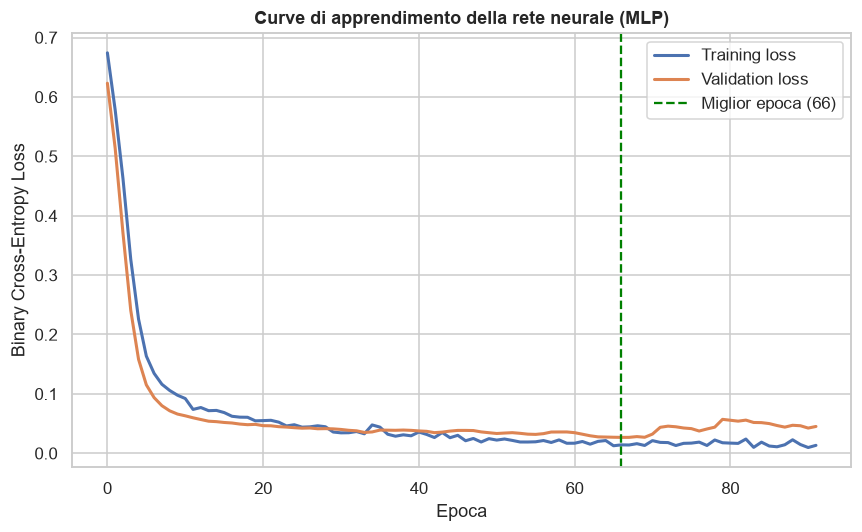

In [13]:
# =====================================================================
# TASK 5a - Deep Learning: rete neurale MLP in PyTorch
# Utilizza ESATTAMENTE lo stesso split (train/val/test) e gli stessi
# dati standardizzati degli algoritmi shallow.
# =====================================================================
# Conversione in tensori PyTorch
Xtr = torch.tensor(X_train_s, dtype=torch.float32)
ytr = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
Xvl = torch.tensor(X_val_s, dtype=torch.float32)
yvl = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
Xte = torch.tensor(X_test_s, dtype=torch.float32)
yte = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


class MLP(nn.Module):
    """Percettrone multi-strato per classificazione binaria."""

    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(RANDOM_STATE)
model_dl = MLP(X_train_s.shape[1])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-4)

g = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32,
                          shuffle=True, generator=g)

MAX_EPOCHS, PATIENCE = 300, 25
best_val_loss, wait, best_state = float("inf"), 0, None
history = {"train_loss": [], "val_loss": []}

for epoch in range(MAX_EPOCHS):
    model_dl.train()
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model_dl(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    train_loss = running / len(Xtr)

    model_dl.eval()
    with torch.no_grad():
        val_loss = criterion(model_dl(Xvl), yvl).item()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Early stopping basato sulla loss di validation
    if val_loss < best_val_loss - 1e-4:
        best_val_loss, wait = val_loss, 0
        best_state = {k: v.clone() for k, v in model_dl.state_dict().items()}
    else:
        wait += 1
        if wait >= PATIENCE:
            break

model_dl.load_state_dict(best_state)
epochs_trained = len(history["train_loss"])
print(f"Addestramento terminato dopo {epochs_trained} epoche "
      f"(early stopping, patience={PATIENCE}).")
print(f"Migliore loss di validation: {best_val_loss:.4f}")

# Curve di apprendimento
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history["train_loss"], label="Training loss", linewidth=2)
ax.plot(history["val_loss"], label="Validation loss", linewidth=2)
best_epoch = int(np.argmin(history["val_loss"]))
ax.axvline(best_epoch, color="green", ls="--",
           label=f"Miglior epoca ({best_epoch})")
ax.set_xlabel("Epoca")
ax.set_ylabel("Binary Cross-Entropy Loss")
ax.set_title("Curve di apprendimento della rete neurale (MLP)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/08_dl_training_curves.png", bbox_inches="tight")
plt.show()

Metriche della rete neurale (MLP) sul TEST set:
  accuracy  : 0.9825
  precision : 0.9859
  recall    : 0.9859
  f1        : 0.9859
  roc_auc   : 0.9941


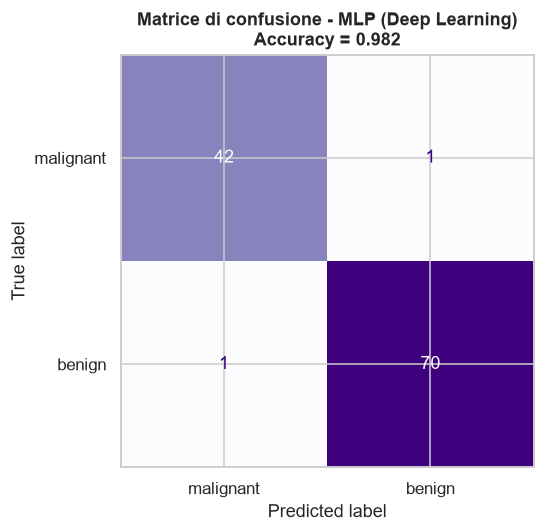

In [14]:
# =====================================================================
# TASK 5a - Valutazione della rete neurale sul TEST set
# =====================================================================
model_dl.eval()
with torch.no_grad():
    logits_test = model_dl(Xte).squeeze().numpy()
proba_dl = 1.0 / (1.0 + np.exp(-logits_test))     # sigmoide -> P(benigno)
pred_dl = (proba_dl >= 0.5).astype(int)

dl_scores = {
    "accuracy": accuracy_score(y_test, pred_dl),
    "precision": precision_score(y_test, pred_dl),
    "recall": recall_score(y_test, pred_dl),
    "f1": f1_score(y_test, pred_dl),
    "roc_auc": roc_auc_score(y_test, proba_dl),
}
print("Metriche della rete neurale (MLP) sul TEST set:")
for k, v in dl_scores.items():
    print(f"  {k:10s}: {v:.4f}")

# Matrice di confusione della rete neurale
fig, ax = plt.subplots(figsize=(5.5, 5))
cm_dl = confusion_matrix(y_test, pred_dl)
ConfusionMatrixDisplay(cm_dl, display_labels=target_names).plot(
    ax=ax, cmap="Purples", colorbar=False, values_format="d")
ax.set_title(f"Matrice di confusione - MLP (Deep Learning)\nAccuracy = {dl_scores['accuracy']:.3f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/09_dl_confusion_matrix.png", bbox_inches="tight")
plt.show()

## Confronto complessivo dei modelli

Mettiamo a confronto **tutti** i modelli (shallow + deep learning) sulle curve ROC e su un grafico a
barre delle metriche, calcolate sullo stesso test set.

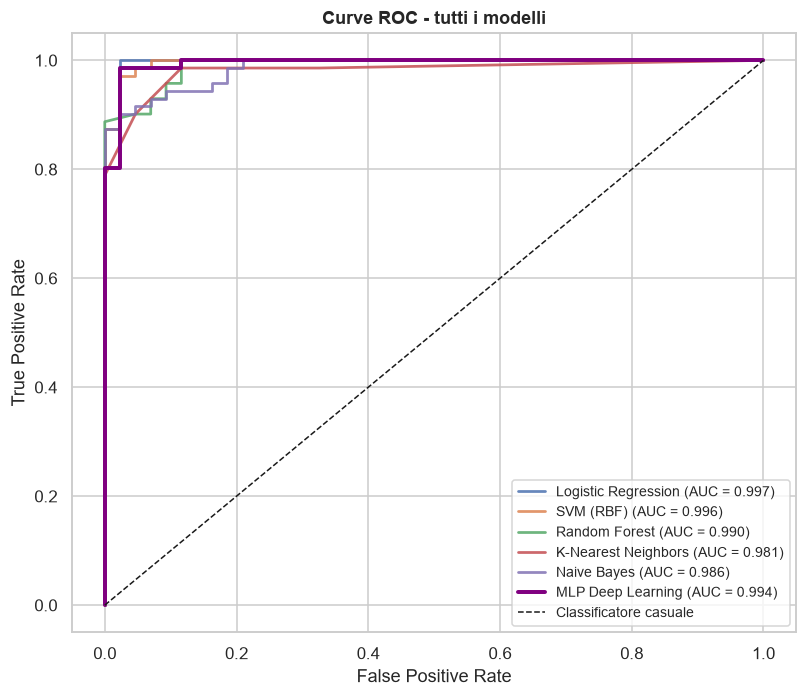

In [15]:
# =====================================================================
# TASK 4/5 - Curve ROC di tutti i modelli (shallow + deep learning)
# =====================================================================
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, res in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, linewidth=1.8, alpha=0.85,
            label=f"{name} (AUC = {res['roc_auc']:.3f})")
fpr_dl, tpr_dl, _ = roc_curve(y_test, proba_dl)
ax.plot(fpr_dl, tpr_dl, linewidth=2.6, color="purple",
        label=f"MLP Deep Learning (AUC = {dl_scores['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Classificatore casuale")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curve ROC - tutti i modelli")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/10_roc_all_models.png", bbox_inches="tight")
plt.show()

Tabella comparativa finale (TEST set):

                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9912     0.9861  1.0000  0.9930   0.9971
SVM (RBF)              0.9649     0.9589  0.9859  0.9722   0.9961
MLP (Deep Learning)    0.9825     0.9859  0.9859  0.9859   0.9941
Random Forest          0.9298     0.9565  0.9296  0.9429   0.9902
Naive Bayes            0.9123     0.9067  0.9577  0.9315   0.9859
K-Nearest Neighbors    0.9474     0.9333  0.9859  0.9589   0.9812


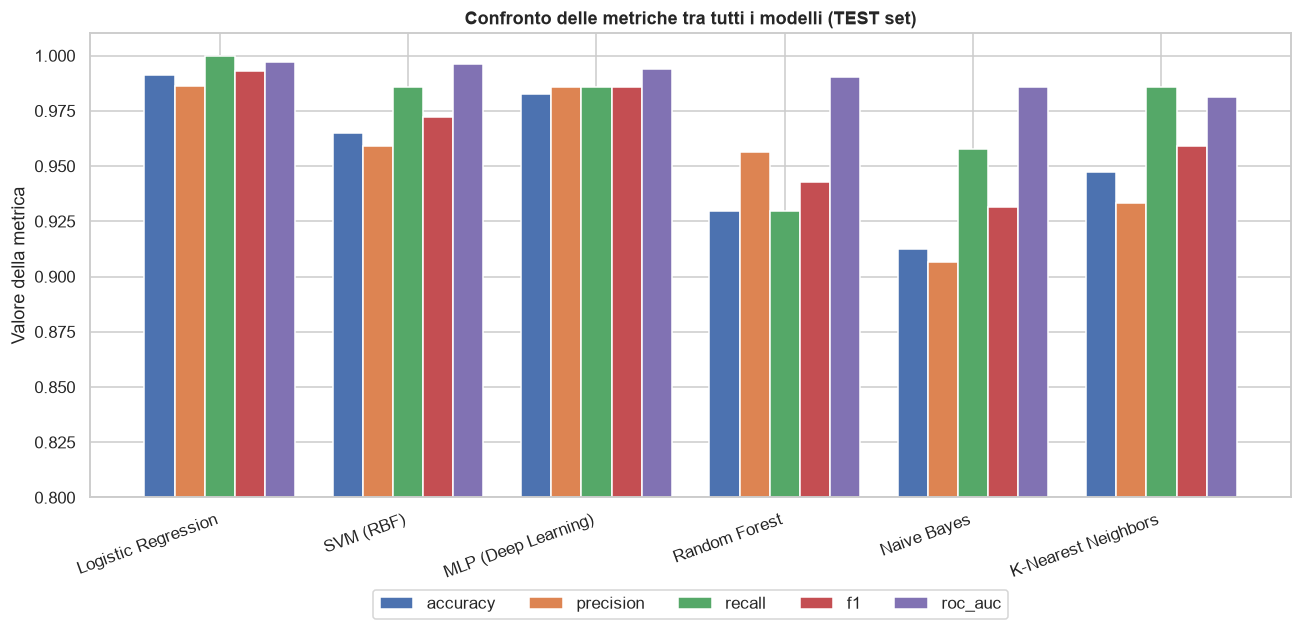

In [16]:
# =====================================================================
# Confronto finale delle metriche: shallow + deep learning
# =====================================================================
final_table = comparison.copy()
final_table.loc["MLP (Deep Learning)"] = [dl_scores[m] for m in metric_cols]
final_table = final_table.sort_values("roc_auc", ascending=False)
print("Tabella comparativa finale (TEST set):\n")
print(final_table.round(4).to_string())

# Grafico a barre raggruppate
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_table))
width = 0.16
palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
for i, m in enumerate(metric_cols):
    ax.bar(x + i * width, final_table[m].values, width, label=m, color=palette[i])
ax.set_xticks(x + width * 2)
ax.set_xticklabels(final_table.index, rotation=20, ha="right")
ax.set_ylabel("Valore della metrica")
ax.set_ylim(0.8, 1.01)
ax.set_title("Confronto delle metriche tra tutti i modelli (TEST set)")
ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.28))
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/11_metrics_comparison.png", bbox_inches="tight")
plt.show()

## Task 5b — Spiegabilità con SHAP

**SHAP (SHapley Additive exPlanations)** attribuisce a ciascuna feature un contributo (positivo o
negativo) alla singola predizione, basandosi sui *valori di Shapley* della teoria dei giochi.
Spieghiamo il modello **Random Forest** con tre visualizzazioni complementari:

- **Beeswarm plot** — importanza *e* direzione dell'effetto di ogni feature su tutto il test set;
- **Bar plot** — importanza media assoluta (ranking globale delle feature);
- **Waterfall plot** — scomposizione della predizione per un **singolo** paziente.

In questo modo il modello, spesso considerato una *black box*, diventa **interpretabile**.

In [17]:
# =====================================================================
# TASK 5b - Spiegabilita' con SHAP (approfondimento aggiuntivo)
# Si spiega il modello Random Forest tramite i valori di Shapley (Shapley
# values), che quantificano il contributo di ogni feature alla predizione.
# =====================================================================
rf_model = models["Random Forest"]
X_test_df = pd.DataFrame(X_test_s, columns=feature_names)

explainer = shap.TreeExplainer(rf_model)
shap_exp = explainer(X_test_df, check_additivity=False)

# Per la classificazione binaria l'oggetto ha shape (n, feature, classi):
# selezioniamo i contributi verso la classe positiva (benigno, label 1).
if len(shap_exp.shape) == 3:
    shap_pos = shap_exp[:, :, 1]
else:
    shap_pos = shap_exp

# Feature piu' importanti secondo SHAP (media dei valori assoluti)
mean_abs = np.abs(shap_pos.values).mean(axis=0)
shap_importance = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False)
print("Top 8 feature per importanza SHAP (Random Forest):")
for f, v in shap_importance.head(8).items():
    print(f"  - {f}: {v:.4f}")

Top 8 feature per importanza SHAP (Random Forest):
  - worst area: 0.0672
  - worst perimeter: 0.0631
  - worst concave points: 0.0528
  - worst radius: 0.0503
  - mean concave points: 0.0363
  - mean radius: 0.0318
  - worst concavity: 0.0249
  - mean perimeter: 0.0248


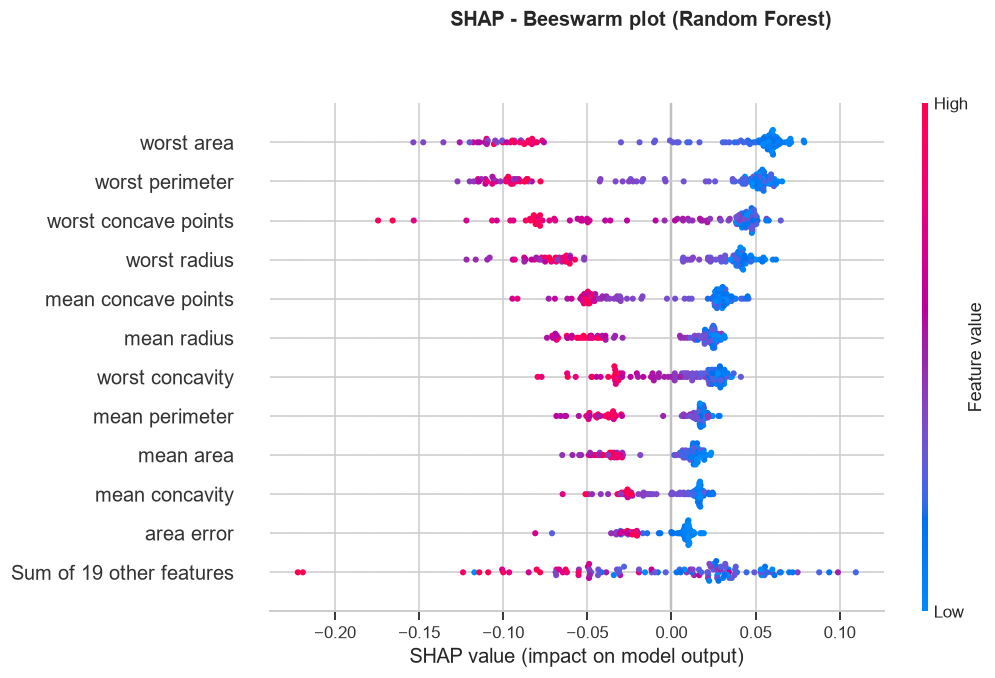

In [18]:
# Beeswarm plot: importanza e direzione dell'effetto di ogni feature.
# plt.close("all") garantisce che SHAP disegni su una figura nuova.
plt.close("all")
shap.plots.beeswarm(shap_pos, max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle("SHAP - Beeswarm plot (Random Forest)",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(f"{FIG_DIR}/12_shap_beeswarm.png", bbox_inches="tight")
plt.show()

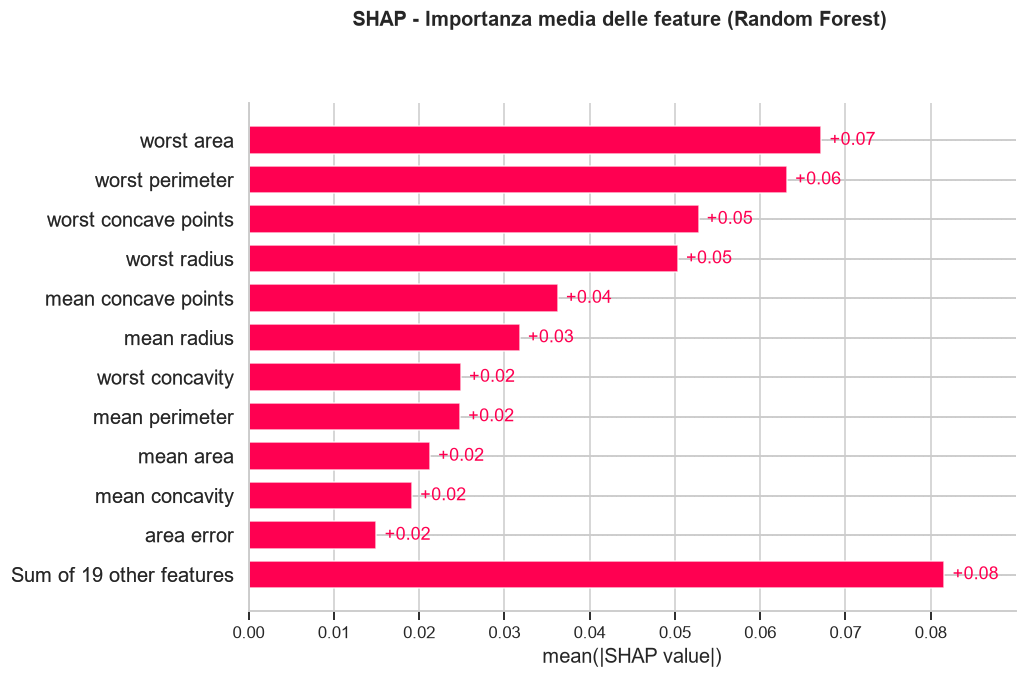

In [19]:
# Bar plot: importanza media assoluta delle feature
plt.close("all")
shap.plots.bar(shap_pos, max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle("SHAP - Importanza media delle feature (Random Forest)",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(f"{FIG_DIR}/13_shap_bar.png", bbox_inches="tight")
plt.show()

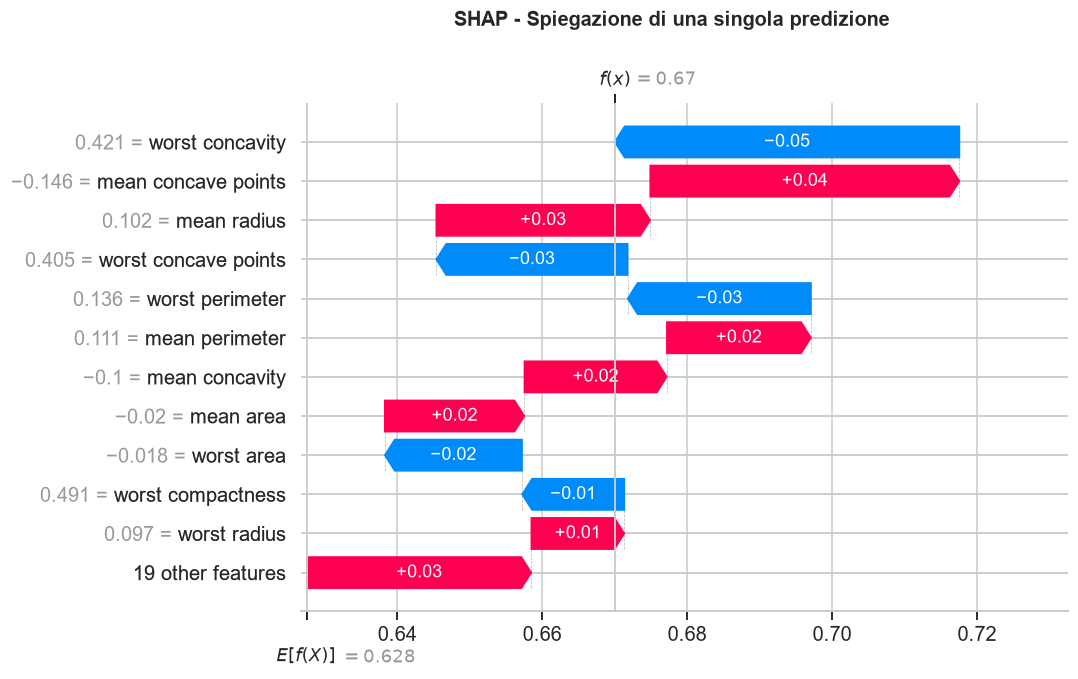

In [20]:
# Waterfall plot: spiegazione di una singola predizione (primo campione del test)
plt.close("all")
shap.plots.waterfall(shap_pos[0], max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle("SHAP - Spiegazione di una singola predizione",
             fontsize=13, fontweight="bold", y=1.02)
fig.savefig(f"{FIG_DIR}/14_shap_waterfall.png", bbox_inches="tight")
plt.show()

## Salvataggio dei risultati

Tutte le metriche e le informazioni principali vengono salvate in `results.json`, usato per generare
automaticamente la relazione PDF. Le figure sono nella cartella `figures/`.

In [21]:
# =====================================================================
# Salvataggio dei risultati su file JSON (usato per la relazione PDF)
# =====================================================================
RESULTS["dataset"] = {
    "name": "Breast Cancer Wisconsin (Diagnostic)",
    "uci_id": 17,
    "n_samples": int(X.shape[0]),
    "n_features": int(X.shape[1]),
    "classes": target_names,
    "class_counts": {target_names[i]: int(c) for i, c in class_counts.items()},
    "n_train": int(X_train.shape[0]),
    "n_val": int(X_val.shape[0]),
    "n_test": int(X_test.shape[0]),
}
RESULTS["pca"] = {
    "explained_variance_ratio": [float(v) for v in evr],
    "cumulative": [float(v) for v in cum_evr],
    "var_pc1_pc2": float(cum_evr[1]),
    "n_components_95": int(n_comp_95),
    "top_features_pc1": list(top_pc1[:5]),
}
RESULTS["shallow_test"] = {
    name: {m: float(test_results[name][m]) for m in metric_cols} for name in models
}
RESULTS["deep_learning"] = {
    **{m: float(dl_scores[m]) for m in metric_cols},
    "epochs_trained": int(epochs_trained),
    "architecture": "MLP 30-64-32-1 (ReLU, Dropout 0.3/0.2)",
}
RESULTS["best_shallow"] = best_shallow
RESULTS["final_ranking"] = [
    {"model": idx, **{m: float(final_table.loc[idx, m]) for m in metric_cols}}
    for idx in final_table.index
]
RESULTS["shap_top_features"] = list(shap_importance.head(8).index)

with open("results.json", "w", encoding="utf-8") as fh:
    json.dump(RESULTS, fh, indent=2, ensure_ascii=False)

print("Risultati salvati in 'results.json'.")
print("Tutte le figure salvate nella cartella 'figures/'.")
plt.close("all")

Risultati salvati in 'results.json'.
Tutte le figure salvate nella cartella 'figures/'.


## Conclusioni

Il progetto ha implementato un esperimento completo di classificazione binaria sul dataset UCI
*Breast Cancer Wisconsin (Diagnostic)*, coprendo tutti i task richiesti.

**Risultati principali:**

- La **PCA** mostra che le prime due componenti spiegano circa il **64%** della varianza e separano
  già visibilmente le due classi; ~10 componenti bastano per il 95% della varianza. Le feature più
  influenti riguardano la **concavità** e le **dimensioni** del nucleo cellulare.
- Tutti e cinque gli algoritmi shallow raggiungono ottime prestazioni; la **Logistic Regression**
  ottiene la ROC AUC più alta (≈ **0.997**) — un risultato coerente con la buona separabilità lineare
  evidenziata dalla PCA.
- La **rete neurale MLP** ottiene prestazioni allineate ai migliori modelli shallow (ROC AUC ≈ **0.994**),
  pur essendo il dataset relativamente piccolo (situazione in cui i modelli shallow restano molto
  competitivi).
- **SHAP** conferma che le feature `worst area`, `worst perimeter` e `worst concave points` sono le più
  determinanti, in accordo con l'analisi PCA e con la letteratura clinica.

**In sintesi**, per questo problema i modelli lineari/shallow sono già estremamente efficaci; il deep
learning offre prestazioni comparabili, mentre l'analisi di spiegabilità aggiunge **trasparenza** alle
decisioni del modello — aspetto cruciale in ambito medico.